# **1. Perkenalan Dataset**


## Dataset yang Digunakan

Dataset yang digunakan pada proyek ini adalah **Breast Cancer Wisconsin (Diagnostic)** dari **UCI Machine Learning Repository**.

- **Sumber**: UCI Machine Learning Repository.
- **URL**: `https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic`
- **Salinan lokal raw dataset**: `../breast_cancer_raw/breast_cancer_raw.csv`
- **Jumlah baris**: 569 sampel.
- **Jumlah fitur asli**: 30 fitur numerik.
- **Target asli**: `diagnosis`, berisi `M` untuk malignant dan `B` untuk benign.
- **Target untuk modelling**: `is_malignant`, yaitu `1` untuk malignant dan `0` untuk benign.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
from pathlib import Path
import json
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TARGET_COLUMN = 'is_malignant'

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
path = Path('../breast_cancer_raw/breast_cancer_raw.csv')

if not path.exists():
    raise FileNotFoundError(f'Dataset raw tidak ditemukan: {path.resolve()}')

df = pd.read_csv(path)

print('Shape dataset:', df.shape)
display(df.head())
display(df.tail())
display(df.info())


Shape dataset: (569, 32)


,sample_id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,1,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,2,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,3,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,4,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,5,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,sample_id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
564,565,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,566,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,567,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,568,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,569,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sample_id                569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   mean_radius              569 non-null    float64
 3   mean_texture             569 non-null    float64
 4   mean_perimeter           569 non-null    float64
 5   mean_area                569 non-null    float64
 6   mean_smoothness          569 non-null    float64
 7   mean_compactness         569 non-null    float64
 8   mean_concavity           569 non-null    float64
 9   mean_concave_points      569 non-null    float64
 10  mean_symmetry            569 non-null    float64
 11  mean_fractal_dimension   569 non-null    float64
 12  radius_error             569 non-null    float64
 13  texture_error            569 non-null    float64
 14  perimeter_error          5

None

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

,count,mean,std,min,25%,50%,75%,max
sample_id,569.0,285.000000,164.400426,1.000000,143.000000,285.000000,427.000000,569.00000
mean_radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean_texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean_perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean_area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean_smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean_compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean_concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean_concave_points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean_symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


Jumlah duplikasi: 0


Series([], dtype: int64)

diagnosis
B    357
M    212
Name: count, dtype: int64

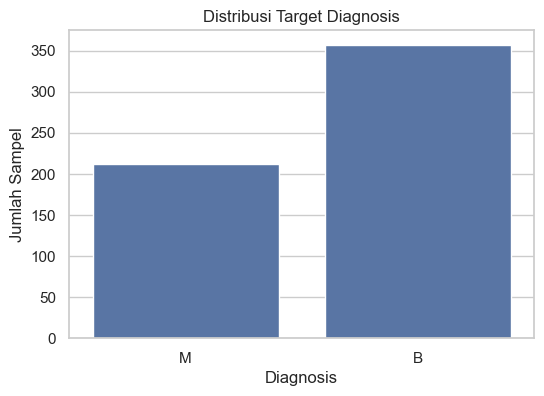

is_malignant            1.000000
worst_concave_points    0.793566
worst_perimeter         0.782914
mean_concave_points     0.776614
worst_radius            0.776454
mean_perimeter          0.742636
worst_area              0.733825
mean_radius             0.730029
mean_area               0.708984
mean_concavity          0.696360
worst_concavity         0.659610
mean_compactness        0.596534
worst_compactness       0.590998
radius_error            0.567134
perimeter_error         0.556141
Name: is_malignant, dtype: float64

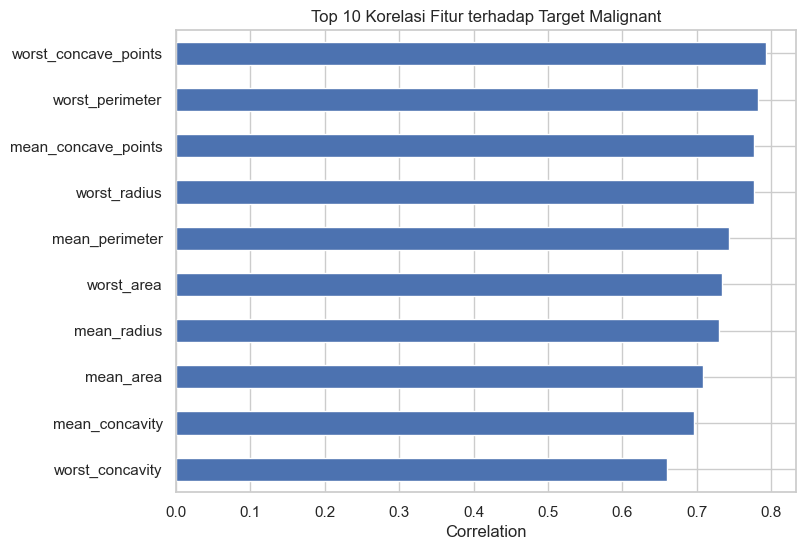

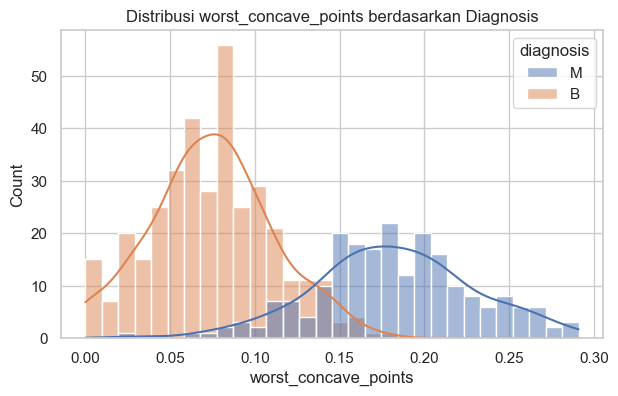

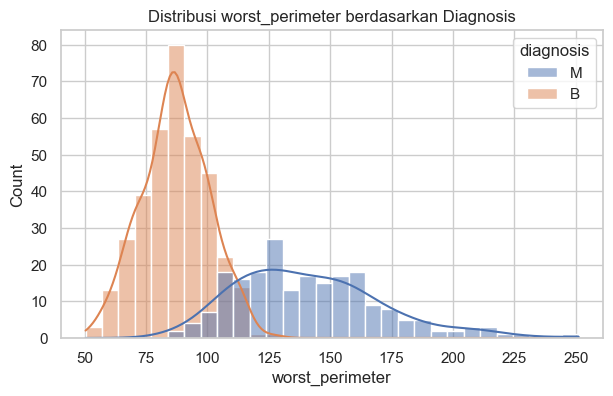

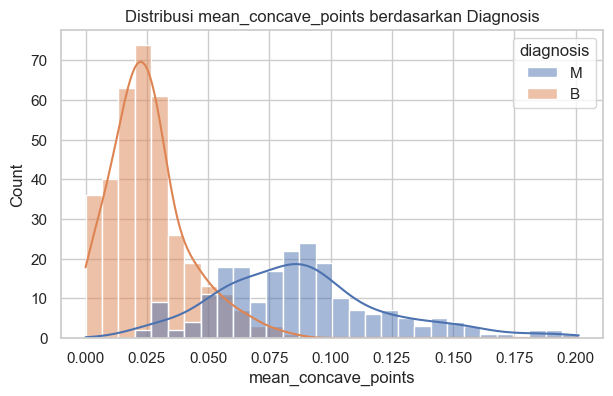

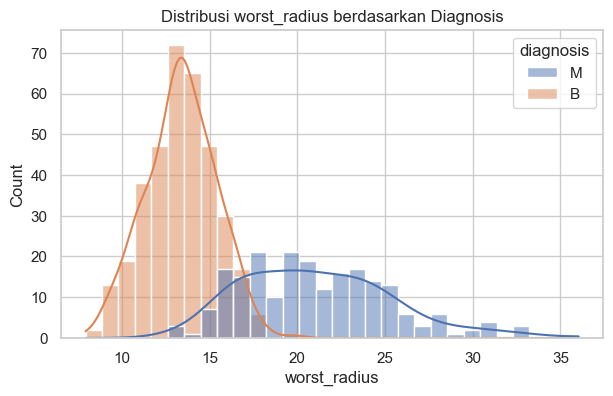

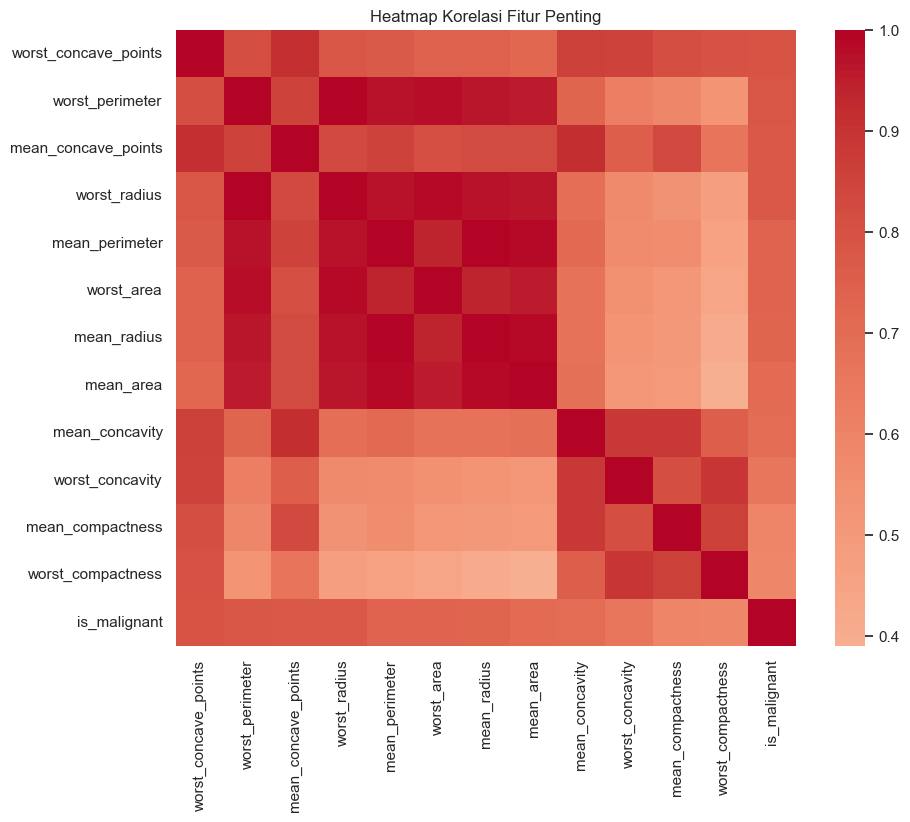

In [6]:
# Ringkasan statistik
display(df.describe().T)

# Cek missing value dan apakah ada duplikasi data
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()

print('Jumlah duplikasi:', duplicate_count)
display(missing_values[missing_values > 0])

# Cek distribusi target
diagnosis_counts = df['diagnosis'].value_counts()
display(diagnosis_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis')
plt.title('Distribusi Target Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah Sampel')
plt.show()

# Korelasi fitur numerik terhadap target
eda_df = df.copy()
eda_df['is_malignant'] = eda_df['diagnosis'].map({'M': 1, 'B': 0})
numeric_cols = eda_df.select_dtypes(include='number').columns.drop(['sample_id'])
corr_target = eda_df[numeric_cols].corr(numeric_only=True)['is_malignant'].sort_values(key=abs, ascending=False)
display(corr_target.head(15))

plt.figure(figsize=(8, 6))
corr_target.drop('is_malignant').head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Korelasi Fitur terhadap Target Malignant')
plt.xlabel('Correlation')
plt.show()

# Visualisasi distribusi beberapa fitur yang dianggap penting
important_features = ['worst_concave_points', 'worst_perimeter', 'mean_concave_points', 'worst_radius']
for feature in important_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=eda_df, x=feature, hue='diagnosis', kde=True, bins=30)
    plt.title(f'Distribusi {feature} berdasarkan Diagnosis')
    plt.show()

# Heatmap fitur penting
top_features = corr_target.drop('is_malignant').abs().head(12).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(eda_df[top_features + ['is_malignant']].corr(), cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Fitur Penting')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
def clean_column_name(name: str) -> str:
    """Ubah nama kolom menjadi snake_case agar penamaanya konsisten."""
    name = name.strip().lower()
    name = re.sub(r'[^a-z0-9]+', '_', name)
    name = re.sub(r'_+', '_', name).strip('_')
    return name

# 1. Standarisasi nama kolom
data = df.copy()
data.columns = [clean_column_name(col) for col in data.columns]

# 2. Hapus duplikasi data
before_drop_duplicate = len(data)
data = data.drop_duplicates()
after_drop_duplicate = len(data)
print('Duplikasi dihapus:', before_drop_duplicate - after_drop_duplicate)

# 3. Validasi dan encoding target (ubah M menjadi 1, dan B menjadi 0)
data['diagnosis'] = data['diagnosis'].astype(str).str.upper().str.strip()
data = data[data['diagnosis'].isin(['M', 'B'])].copy()
data[TARGET_COLUMN] = data['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# 4. Pisahkan fitur dan target
drop_columns = ['sample_id', 'diagnosis']
X = data.drop(columns=drop_columns + [TARGET_COLUMN])
y = data[TARGET_COLUMN]

# 5. Pastikan fitur numerik valid dan ubah missing value dengan median
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

missing_before = X.isna().sum()
X = X.fillna(X.median(numeric_only=True))
print('Missing value sebelum imputasi:')
display(missing_before[missing_before > 0])

# 6. Penanganan outlier menggunakan IQR capping
cap_bounds = {}
X_capped = X.copy()
for col in X_capped.columns:
    q1 = X_capped[col].quantile(0.25)
    q3 = X_capped[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    cap_bounds[col] = {'lower': float(lower), 'upper': float(upper)}
    X_capped[col] = X_capped[col].clip(lower=lower, upper=upper)

# 7. Train-test split stratified agar proporsi kelas tetap seimbang
full_data = X_capped.copy()
full_data[TARGET_COLUMN] = y.values

train_df, test_df = train_test_split(
    full_data,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=full_data[TARGET_COLUMN]
)

feature_columns = X_capped.columns.tolist()
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(train_df[feature_columns]),
    columns=feature_columns,
    index=train_df.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(test_df[feature_columns]),
    columns=feature_columns,
    index=test_df.index
)

train_preprocessed = X_train_scaled.copy()
train_preprocessed[TARGET_COLUMN] = train_df[TARGET_COLUMN].astype(int).values

test_preprocessed = X_test_scaled.copy()
test_preprocessed[TARGET_COLUMN] = test_df[TARGET_COLUMN].astype(int).values

full_preprocessed = pd.concat([train_preprocessed, test_preprocessed], axis=0).sort_index()

# 8. Simpan hasil preprocessing agar bisa dipakai untuk modelling dan workflow CI
output_dir = Path('breast_cancer_preprocessing')
output_dir.mkdir(parents=True, exist_ok=True)

train_preprocessed.to_csv(output_dir / 'train.csv', index=False)
test_preprocessed.to_csv(output_dir / 'test.csv', index=False)
full_preprocessed.to_csv(output_dir / 'full_preprocessed.csv', index=False)

joblib.dump(
    {
        'scaler': scaler,
        'feature_columns': feature_columns,
        'target_column': TARGET_COLUMN,
        'target_mapping': {'M': 1, 'B': 0},
        'iqr_cap_bounds': cap_bounds,
        'source_dataset': 'UCI Breast Cancer Wisconsin (Diagnostic)'
    },
    output_dir / 'preprocessor.joblib'
)

metadata = {
    'dataset_name': 'Breast Cancer Wisconsin (Diagnostic)',
    'source': 'UCI Machine Learning Repository',
    'url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic',
    'target_column': TARGET_COLUMN,
    'target_definition': {'0': 'benign', '1': 'malignant'},
    'raw_rows': int(len(df)),
    'clean_rows': int(len(full_data)),
    'train_rows': int(len(train_preprocessed)),
    'test_rows': int(len(test_preprocessed)),
    'feature_count': int(len(feature_columns)),
    'feature_columns': feature_columns,
    'random_state': RANDOM_STATE
}

preprocessing_report = {
    'duplicates_removed': int(before_drop_duplicate - after_drop_duplicate),
    'missing_values_before_imputation': {k: int(v) for k, v in missing_before.to_dict().items()},
    'outlier_method': 'IQR capping',
    'scaling_method': 'StandardScaler fitted only on training split',
    'class_distribution_full': {str(k): int(v) for k, v in full_data[TARGET_COLUMN].value_counts().sort_index().to_dict().items()},
    'train_shape': list(train_preprocessed.shape),
    'test_shape': list(test_preprocessed.shape)
}

(output_dir / 'metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')
(output_dir / 'feature_columns.json').write_text(json.dumps({'features': feature_columns, 'target': TARGET_COLUMN}, indent=2), encoding='utf-8')
(output_dir / 'preprocessing_report.json').write_text(json.dumps(preprocessing_report, indent=2), encoding='utf-8')

print('Dataset preprocessing telah disimpan di:', output_dir.resolve())
display(train_preprocessed.head())
display(test_preprocessed.head())


Duplikasi dihapus: 0
Missing value sebelum imputasi:


Series([], dtype: int64)

Dataset preprocessing telah disimpan di: D:\pijak\Proyek Membangun Sistem Machine learning\SMSML_Nikolas_Febrianto_UCI_BreastCancer\_source_repositories\Eksperimen_SML_Nikolas_Febrianto\preprocessing\breast_cancer_preprocessing


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,is_malignant
10,0.575860,0.927576,0.474940,0.510883,-0.996070,-0.720020,-0.722292,-0.401095,-1.079296,-0.868734,-0.039167,-0.021374,-0.178135,0.214525,-1.159900,-1.016928,-0.923374,-0.708875,-0.810396,-0.297842,0.636346,1.339501,0.513837,0.614000,-0.603120,-0.668231,-0.630388,-0.235744,0.114101,0.064065,1
170,-0.527084,-1.679708,-0.554273,-0.581616,0.500573,-0.657225,-0.630167,-0.302453,0.568148,-0.467329,-0.736680,-1.116879,-0.738969,-0.728017,0.536667,-0.847403,-0.638380,0.174923,-0.104363,-0.745551,-0.596529,-1.712617,-0.627470,-0.643229,0.287993,-0.866734,-0.739727,-0.323208,-0.109444,-0.990300,0
407,-0.369095,0.478210,-0.391153,-0.416611,-1.468732,-0.388534,-0.343751,-0.782057,-0.880532,-0.219951,0.543147,1.262389,-0.117543,0.244337,-0.322600,1.362922,1.071585,0.358322,1.029247,2.346126,-0.401523,0.189937,-0.483064,-0.440909,-1.654982,-0.400078,-0.439422,-0.890825,-0.735738,-0.124730,0
430,0.241996,0.756961,0.449048,0.141588,0.260273,2.415911,2.495501,1.270324,0.881582,0.999824,-0.654048,-0.677122,0.526430,-0.451952,0.080419,2.481816,2.418697,1.996072,-0.751053,1.248279,0.020992,0.283643,0.563418,-0.049869,0.436512,2.618210,2.592349,1.977064,-0.037392,2.007209,1
27,1.347921,0.209071,1.312119,1.480610,-0.105589,0.083234,0.831102,0.752257,-0.433315,-0.865622,2.241238,1.369544,2.052518,2.080417,1.679399,0.185422,1.025555,1.403695,0.457117,0.364701,1.095695,0.231770,1.012752,1.143337,0.082688,-0.274011,0.370797,0.501859,-1.007316,-0.582604,1


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,is_malignant
120,-0.798349,-2.056983,-0.792049,-0.780668,-0.153938,-0.716800,-0.693770,-0.584250,-0.547986,-0.221507,-1.199421,-1.547391,-1.138458,-1.011025,-0.310349,-0.613644,-0.721136,-0.916299,-0.986905,-0.769234,-0.743867,-1.657397,-0.727563,-0.723989,1.000010,-0.083867,-0.306401,-0.388057,0.239729,0.108598,0
250,2.042477,1.004473,2.037099,2.241136,0.349032,1.170073,2.467382,2.157055,1.508452,-0.556011,2.241238,-0.790790,2.300173,2.080417,-0.630145,0.979799,2.576864,1.317497,0.621452,0.807336,2.020892,0.188264,1.799860,2.260699,-0.472074,0.460797,2.157007,1.422926,0.442951,-0.314152,1
375,0.620574,-0.795394,0.630293,0.480436,0.211924,0.831945,-0.273453,0.141566,0.686641,0.492622,-1.035614,-1.487930,-0.965135,-0.830929,-0.956700,-0.424092,-0.507145,0.092394,-0.089146,0.070927,0.155330,-1.126958,0.182259,0.010388,-0.367237,0.027574,-0.300355,0.143916,0.492833,0.382696,0
99,0.098911,0.093726,0.120217,0.002447,0.119557,0.234184,0.093036,0.257216,0.262358,0.209460,-0.476632,1.373746,-0.241546,-0.343323,0.519769,0.301297,0.163717,0.510543,-0.807353,0.497209,0.016658,0.834162,0.070701,-0.063050,0.488930,0.359108,0.243822,0.614184,-0.310818,0.629195,1
455,-0.211105,2.610896,-0.231053,-0.276816,-0.246305,-0.567661,-0.786564,-0.416532,-1.664119,-0.372423,-0.227277,1.527125,-0.304253,-0.258380,-0.394417,-0.803196,-1.073902,-0.426991,-0.652147,-0.329982,-0.260684,2.632970,-0.326262,-0.315793,-0.642434,-0.758776,-1.012672,-0.567029,-1.275200,-0.423289,0
